# Lensed AGN Population with Multi-Survey Variability
This notebook simulates a lensed quasar population using `slsim`, showcasing rendering 
and microlensing extraction across LSST, Roman, and Euclid observatories.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import vstack, Table

import speclite.filters
import slsim
import slsim.Sources as sources
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
from slsim.ImageSimulation.image_simulation import simulate_image, rgb_image_from_image_list
from slsim.Util.astro_util import theta_star_physical

from slsim.Pipelines import roman_speclite
from slsim.ImageSimulation.image_quality_lenstronomy import ROMAN_BAND_LIST, LSST_BAND_LIST, EUCLID_BAND_LIST

%load_ext autoreload
%autoreload 2

## 1. Kcorrect Template Hotfix & Filter Setup
`kcorrect` templates occasionally struggle with extrapolations for extremely blue filters 
below ~3500 Angstroms. We patch `photometry.SpectrumTemplates` to safely pad wavelengths 
to avoid evaluation errors before loading the configurations.

In [ ]:
import skypy.utils.photometry as photometry

if not hasattr(photometry.SpectrumTemplates, "_is_mag_patched"):
    original_app = photometry.SpectrumTemplates.apparent_magnitudes
    original_abs = photometry.SpectrumTemplates.absolute_magnitudes

    def _pad_templates(self):
        min_wave_val = 100.0
        if hasattr(self.wavelength, 'unit'):
            wave_unit, wave_vals = self.wavelength.unit, self.wavelength.value
            temp_unit, temp_vals = self.templates.unit, self.templates.value
        else:
            wave_unit, wave_vals = None, self.wavelength
            temp_unit, temp_vals = None, self.templates

        if wave_vals[0] > min_wave_val:
            pad_wave = np.linspace(min_wave_val, wave_vals[0] - 0.1, 500)
            if temp_vals.shape[0] == len(wave_vals):
                pad_temp = np.full((len(pad_wave),) + temp_vals.shape[1:], 1e-30)
                temp_vals = np.concatenate([pad_temp, temp_vals], axis=0)
            elif temp_vals.shape[-1] == len(wave_vals):
                pad_temp = np.full(temp_vals.shape[:-1] + (len(pad_wave),), 1e-30)
                temp_vals = np.concatenate([pad_temp, temp_vals], axis=-1)
            wave_vals = np.concatenate([pad_wave, wave_vals])
            self.wavelength = wave_vals * wave_unit if wave_unit else wave_vals
            self.templates = temp_vals * temp_unit if temp_unit else temp_vals

    def patched_app(self, *args, **kwargs):
        _pad_templates(self); return original_app(self, *args, **kwargs)

    def patched_abs(self, *args, **kwargs):
        _pad_templates(self); return original_abs(self, *args, **kwargs)

    photometry.SpectrumTemplates.apparent_magnitudes = patched_app
    photometry.SpectrumTemplates.absolute_magnitudes = patched_abs
    photometry.SpectrumTemplates._is_mag_patched = True

# %%
roman_speclite.configure_roman_filters()

filters = speclite.filters.load_filters(
    "Euclid-VIS",
    "Roman-F062", "Roman-F087", "Roman-F106", "Roman-F129", "Roman-F158", "Roman-F184", "Roman-F146", "Roman-F213",
    "lsst2023-u", "lsst2023-g", "lsst2023-r", "lsst2023-i", "lsst2023-z", "lsst2023-y",
)

# visualize the filters
filters.plot()

## 2. Population Setup (SkyPy Pipeline & QuasarRate)

In [3]:

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area = Quantity(value=5, unit="deg2")

# Using a standard path for Euclid/Roman/LSST defaults
path = os.path.dirname(slsim.__file__)
skypy_config_path = os.path.join(os.path.split(path)[0], "data/SkyPy/euclid-roman-lsst-like.yml")

galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config_path, sky_area=sky_area, filters=None, cosmo=cosmo, z_min=0.0, z_max=3.0, 
)

host_galaxy_candidates = vstack([galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies], join_type="exact")

lens_galaxies = deflectors.AllLensGalaxies(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut={"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5},
    kwargs_mass2light={}, cosmo=cosmo, sky_area=sky_area,
)

all_qsogen_bands = LSST_BAND_LIST + ROMAN_BAND_LIST + EUCLID_BAND_LIST

print("Generating quasar catalog...")
quasar_class = QuasarRate(
    skypy_config=skypy_config_path, cosmo=cosmo, sky_area=sky_area, noise=True,
    redshifts=np.linspace(0.001, 3.01, 100), host_galaxy_candidate=host_galaxy_candidates,
    use_qsogen_sed=True, qsogen_bands=all_qsogen_bands, use_sed_interpolator=True,
)
quasar_source = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)

source_quasar = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_source, cosmo=cosmo, sky_area=sky_area,
    kwargs_cut={"band": "i", "band_max": 26, "z_min": 0.001, "z_max": 5.0},
    list_type="astropy_table", catalog_type="skypy",
    point_source_type="quasar", extended_source_type="single_sersic",
    point_source_kwargs={
        "variability_model": "light_curve",
        "kwargs_variability": set(all_qsogen_bands),
        "agn_driving_variability_model": "bending_power_law",
        "agn_driving_kwargs_variability": {
            "length_of_light_curve": 35000, "time_resolution": 1,
            "log_breakpoint_frequency": 1 / 20, "low_frequency_slope": 1,
            "high_frequency_slope": 3, "standard_deviation": 0.9,
        },
        "lightcurve_time": np.linspace(-5000, 30000, 35000), "corona_height": 10, "r_resolution": 500,
    },
)

/global/u1/s/sharma/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:56: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  red_galaxy_list = catalog_with_angular_size_in_arcsec(
/global/u1/s/sharma/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:59: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  blue_galaxy_list = catalog_with_angular_size_in_arcsec(


Generating quasar catalog...


/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/qsogen/qsosed.py:67: RuntimeWarning: overflow encountered in exp
  return (wav ** (-3)) / (np.exp(1.43877735e8 / (tbb * wav)) - 1.0)
Matching quasars with host galaxies:   6%|▌         | 2596/42695 [00:01<00:18, 2167.58it/s]/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/quasar_host_match.py:123: RuntimeWarning: divide by zero encountered in log10
  M_bol = M_bol_sun - 2.5 * np.log10(L_bol)  # L_sun
Matching quasars with host galaxies: 100%|██████████| 42695/42695 [00:19<00:00, 2182.76it/s]


## 3. Lens Selection & Static Image Simulation
We draw the population and pick an ideal Quad lens for visualization across the observatories.

LENS SYSTEM: z_s=2.6560 | z_l=1.5750 | R_E=0.9465 arcsec


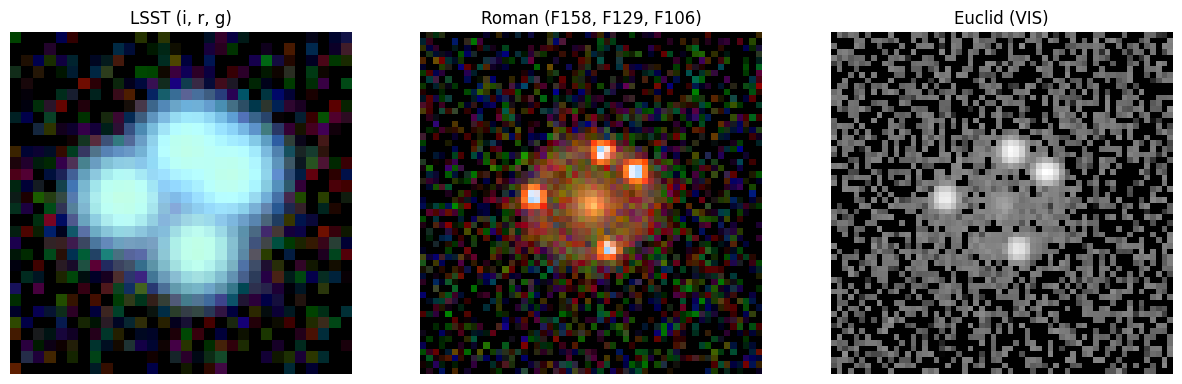

In [ ]:
quasar_lens_pop = LensPop(deflector_population=lens_galaxies, source_population=source_quasar, cosmo=cosmo, sky_area=sky_area * 100)
selected_lenses = quasar_lens_pop.draw_population(kwargs_lens_cuts={"min_image_separation": 1, "max_image_separation": 10, "second_brightest_image_cut": {"i": 26}}, speed_factor=10000)

quad_lenses = [lens for lens in selected_lenses if lens.image_number[0] == 4]
lens_class = quad_lenses[np.argmax([lens.einstein_radius[0] for lens in quad_lenses])]

print("=" * 50)
print(f"LENS SYSTEM: z_s={lens_class.source_redshift_list[0]:.4f} | z_l={lens_class.deflector_redshift:.4f} | R_E={lens_class.einstein_radius[0]:.4f} arcsec")
print("=" * 50)

# Simulate RGB Composites
FOV = 6 # arcsec
lsst_images = [simulate_image(lens_class, band=b, observatory="LSST", num_pix=int(FOV/0.2), microlensing=True) for b in ["i", "r", "g"]]
roman_images = [simulate_image(lens_class, band=b, observatory="Roman", num_pix=int(FOV/0.11), microlensing=True) for b in ["F158", "F129", "F106"]]
euclid_img = simulate_image(lens_class, band="VIS", observatory="Euclid", num_pix=int(FOV/0.1), microlensing=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_image_from_image_list(lsst_images, stretch=0.5), origin='lower'); axes[0].set_title("LSST (i, r, g)")
axes[1].imshow(rgb_image_from_image_list(roman_images, stretch=0.5), origin='lower'); axes[1].set_title("Roman (F158, F129, F106)")
axes[2].imshow(np.log10(np.clip(euclid_img, 1e-5, None)), origin='lower', cmap='gray'); axes[2].set_title("Euclid (VIS)")
for ax in axes: ax.axis('off')
plt.show()

## 4. Chromatic Microlensing Extractions
We extract 10-year microlensing lightcurves across the observatories, showcasing isolated residuals.


In [12]:
# Recompute magmaps
# del lens_class._microlensing_model_class[0]
# Reset track starting position
lens_class.microlensing_model_class(0).reset_start_position(x_start_position=-2*theta_E_micro, y_start_position=-1*theta_E_micro)

(np.float64(-2.1609118016747683e-06), np.float64(-1.0804559008373842e-06))

Processing Multi-Band Macrolensing and Microlensing...
Visualizing Continuous Macrolensing + Microlensing Signatures...


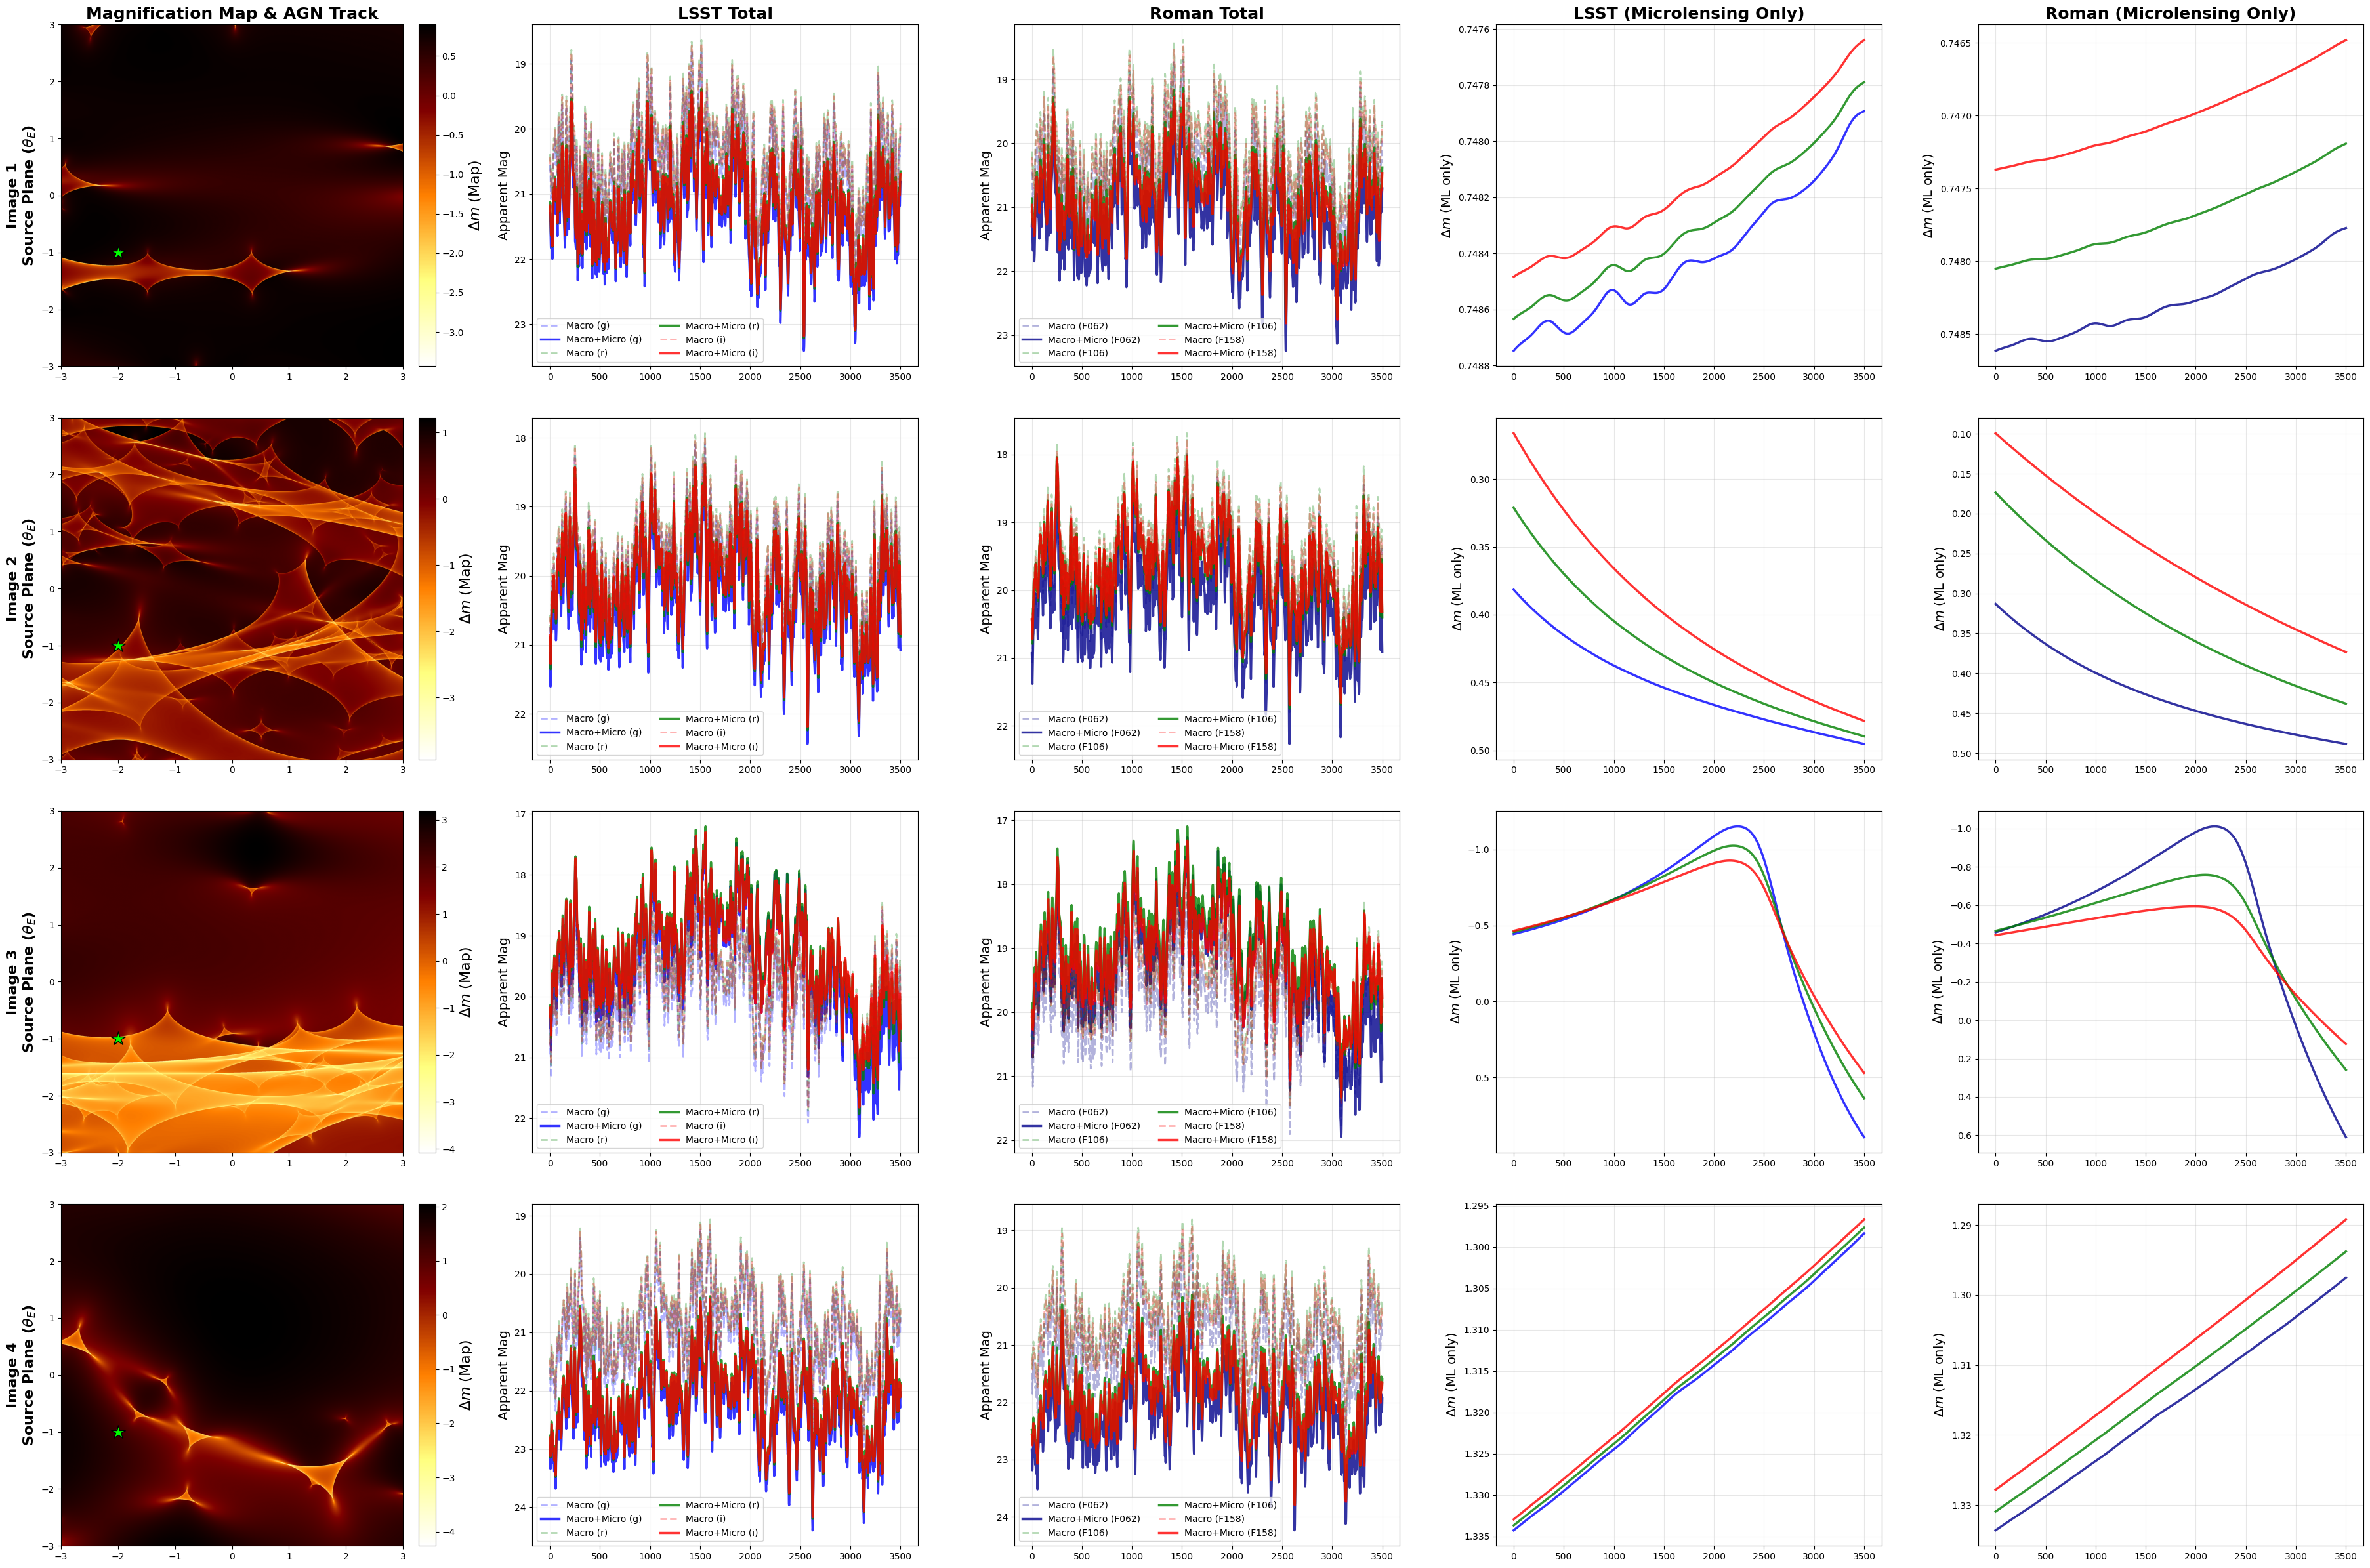

In [13]:
compare_lsst = ["g", "r", "i"]
compare_roman = ["F062", "F106", "F158"]
t_test = np.linspace(0, 3500, 3500) 

theta_E_micro_arcsec, _, _ = theta_star_physical(z_lens=lens_class.deflector_redshift, z_src=lens_class.source_redshift_list[0], cosmo=cosmo, m=1.0)
theta_E_micro = theta_E_micro_arcsec.value 

kwargs_micro = {
    "kwargs_magnification_map": {
        "theta_star": theta_E_micro, "half_length_x": 3 * theta_E_micro, "half_length_y": 3 * theta_E_micro,
        "num_pixels_x": 2000, "num_pixels_y": 2000
    },
    "point_source_morphology": "agn", "kwargs_source_morphology": {} 
}

print("Processing Multi-Band Macrolensing and Microlensing...")
lsst_macro, lsst_micro, roman_macro, roman_micro = {}, {}, {}, {}

for band in compare_lsst:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    lsst_macro[band] = lens_class.point_source_magnitude(band=band, time=t_test, lensed=True, microlensing=False)[0] 
    lsst_micro[band] = lens_class.point_source_magnitude(band=band, time=t_test, lensed=True, microlensing=True, kwargs_microlensing=kwargs_micro)[0] 

for band in compare_roman:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    roman_macro[band] = lens_class.point_source_magnitude(band=band, time=t_test, lensed=True, microlensing=False)[0] 
    roman_micro[band] = lens_class.point_source_magnitude(band=band, time=t_test, lensed=True, microlensing=True, kwargs_microlensing=kwargs_micro)[0] 

lcm = lens_class.microlensing_model_class(source_index=0)
num_images = lens_class.image_number[0]

# %%
print("Visualizing Continuous Macrolensing + Microlensing Signatures...")

fig, axes = plt.subplots(num_images, 5, figsize=(36, 6 * num_images)) 
if num_images == 1: axes = np.atleast_2d(axes)

colors = {"g": "blue", "r": "green", "i": "red", "F062": "darkblue", "F106": "green", "F158": "red"}

for i in range(num_images):
    ax_map, ax_lsst, ax_roman, ax_lsst_ml, ax_roman_ml = axes[i]
    
    # -------------------------------------------------------------
    # PANEL A: Magnification Map & Track
    # -------------------------------------------------------------
    magmap = lcm.magmaps_images[i]
    track_x, track_y = lcm.tracks[i][0]
    hl_te = magmap.half_length_x / theta_E_micro
    tx_te = (track_x / magmap.num_pixels_x) * (2 * hl_te) - hl_te
    ty_te = (track_y / magmap.num_pixels_x) * (2 * hl_te) - hl_te
    
    im = ax_map.imshow(-2.5 * np.log10(magmap.magnifications / np.abs(magmap.mu_ave)), origin='lower', cmap='afmhot_r', extent=[-hl_te, hl_te, -hl_te, hl_te])
    ax_map.plot(tx_te, ty_te, color='cyan', lw=2, linestyle='--')
    ax_map.plot(tx_te[0], ty_te[0], marker='*', color='lime', markersize=16, markeredgecolor='black', zorder=10)
    ax_map.set_ylabel(f"Image {i+1}\nSource Plane ($\\theta_E$)", fontweight='bold', fontsize=16)
    plt.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04).set_label(r'$\Delta m$ (Map)', fontsize=16)

    # -------------------------------------------------------------
    # PANELS B & D: LSST Total & Micro-Only
    # -------------------------------------------------------------
    for band in compare_lsst:
        c = colors.get(band, "black")
        ax_lsst.plot(t_test, lsst_macro[band][i], color=c, linestyle='--', lw=2, alpha=0.3, label=f"Macro ({band})")
        ax_lsst.plot(t_test, lsst_micro[band][i], color=c, lw=2.5, alpha=0.8, label=f"Macro+Micro ({band})")
        ax_lsst_ml.plot(t_test, lsst_micro[band][i] - lsst_macro[band][i], color=c, lw=2.5, alpha=0.8, label=f"ML Only ({band})")
    
    ax_lsst.invert_yaxis(); ax_lsst_ml.invert_yaxis()
    ax_lsst.set_ylabel("Apparent Mag", fontsize=14); ax_lsst_ml.set_ylabel(r"$\Delta m$ (ML only)", fontsize=14)
    ax_lsst.legend(fontsize=10, ncol=2); ax_lsst.grid(True, alpha=0.3); ax_lsst_ml.grid(True, alpha=0.3)

    # -------------------------------------------------------------
    # PANELS C & E: Roman Total & Micro-Only
    # -------------------------------------------------------------
    for band in compare_roman:
        c = colors.get(band, "black")
        ax_roman.plot(t_test, roman_macro[band][i], color=c, linestyle='--', lw=2, alpha=0.3, label=f"Macro ({band})")
        ax_roman.plot(t_test, roman_micro[band][i], color=c, lw=2.5, alpha=0.8, label=f"Macro+Micro ({band})")
        ax_roman_ml.plot(t_test, roman_micro[band][i] - roman_macro[band][i], color=c, lw=2.5, alpha=0.8, label=f"ML Only ({band})")

    ax_roman.invert_yaxis(); ax_roman_ml.invert_yaxis()
    ax_roman.set_ylabel("Apparent Mag", fontsize=14); ax_roman_ml.set_ylabel(r"$\Delta m$ (ML only)", fontsize=14)
    ax_roman.legend(fontsize=10, ncol=2); ax_roman.grid(True, alpha=0.3); ax_roman_ml.grid(True, alpha=0.3)

    if i == 0:
        ax_map.set_title("Magnification Map & AGN Track", fontsize=18, fontweight='bold')
        ax_lsst.set_title("LSST Total", fontsize=18, fontweight='bold')
        ax_roman.set_title("Roman Total", fontsize=18, fontweight='bold')
        ax_lsst_ml.set_title("LSST (Microlensing Only)", fontsize=18, fontweight='bold')
        ax_roman_ml.set_title("Roman (Microlensing Only)", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.15) 
plt.show()